# Plotting CMB map from the Planck data
Using the commander .fits file

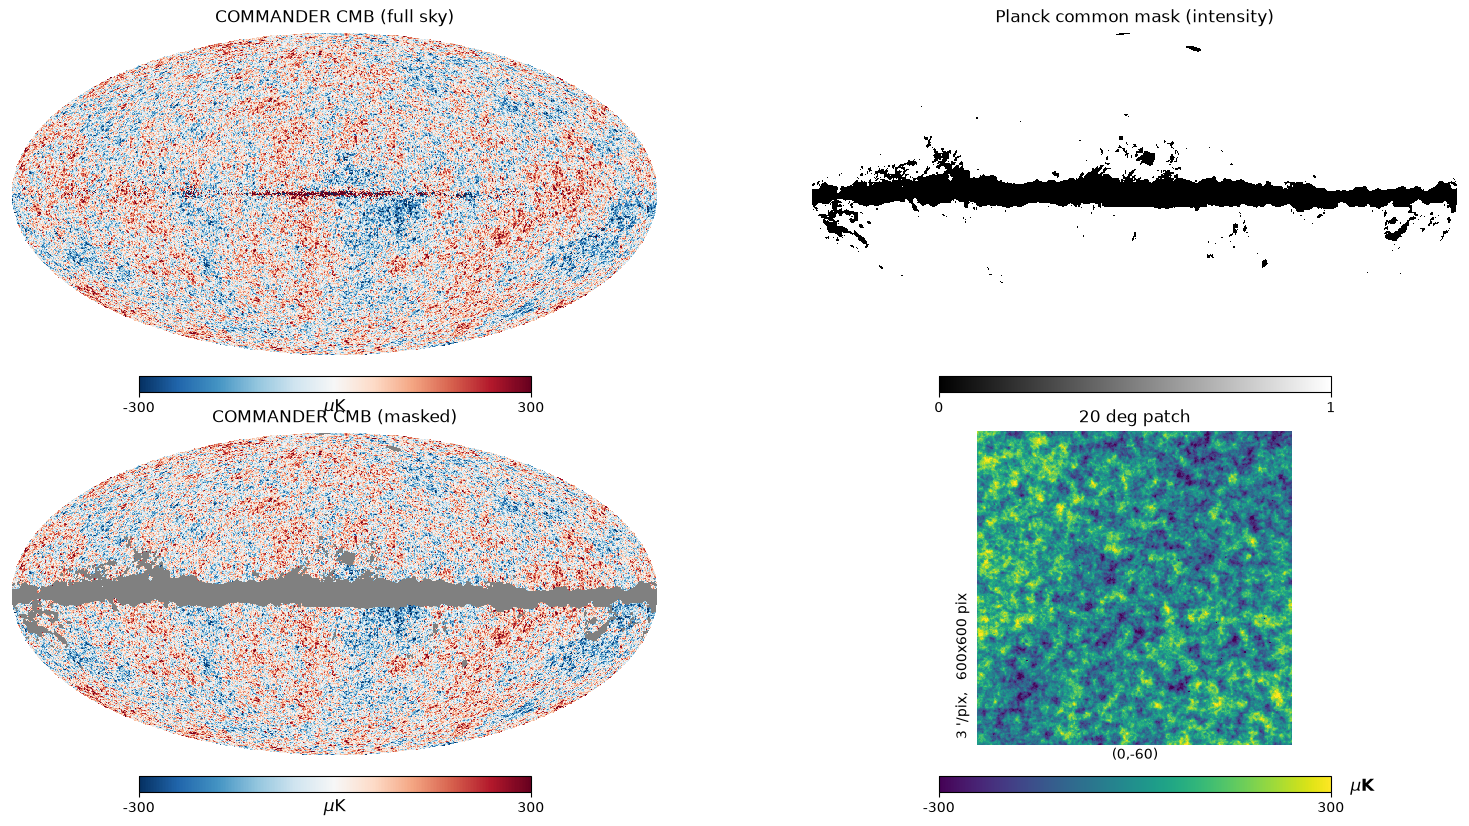

In [5]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# ---- Load ----
cmb, mask = hp.read_map("Plancks Data/COM_CMB_IQU-commander_2048_R3.00_full.fits", field=(0, 3))

cmb *= 1e6          # K -> microK
masked = cmb * mask

fig = plt.figure(figsize=(16, 8)) # For Healpy, plt.subplots doesn't work, so we use the 'sub' parameter for plotting the spheres together in a single plot. 

# ---- Maps ----
hp.mollview(cmb, min=-300, max=300, unit=r"$\mu$K",
            title="COMMANDER CMB (full sky)", cmap="RdBu_r", sub=(2, 2, 1))

hp.mollview(mask, title="Planck common mask (intensity)", cmap="gray", sub=(2, 2, 2))

masked_plot = np.where(mask > 0, masked, hp.UNSEEN) 

hp.mollview(masked_plot, min=-300, max=300, unit=r"$\mu$K",
            title="COMMANDER CMB (masked)", cmap="RdBu_r", sub=(2, 2, 3))

# gnomview zoom on a patch, to see the ~1 degree hot/cold spots
hp.gnomview(masked_plot, rot=(0, -60), xsize=600, reso=3,
            min=-300, max=300, unit=r"$\mu$K", title="20 deg patch", sub=(2, 2, 4))


plt.savefig("Saved Data/CMB_Sky.png", dpi=300, bbox_inches="tight")
plt.show()


## Plotting $\ell$ vs $D_\ell$ from the masked CMB map

$b_\ell$ and $p_\ell$ are the beam and pixel window functions, respectively. 


We are using $b_\ell$ and $p_\ell$ to correct the power spectrum for the effects of the instrument's beam and the pixelization of the map. 

---
We are taking the Angular power spectrum $C_\ell$: $$C_\ell = \langle \vert{}a_{\ell m}\vert{}^2 \rangle \quad \text{(for each $\ell$)}$$
from the masked CMB map. But since $C_\ell$ falls off quickly as $\ell$ increases (plotting $C_\ell$ vs $\ell$ makes it hard to see the acoustic peaks at higher multipoles ($\ell > 200$) alongside the low-$\ell$ signal {See file `l_vs_cl&dl.py`}), We plot $\ell$ vs $D_\ell$ (Bandpower / Temperature Variance): $$D_\ell = \frac{\ell(\ell + 1)}{2\pi} C_\ell$$

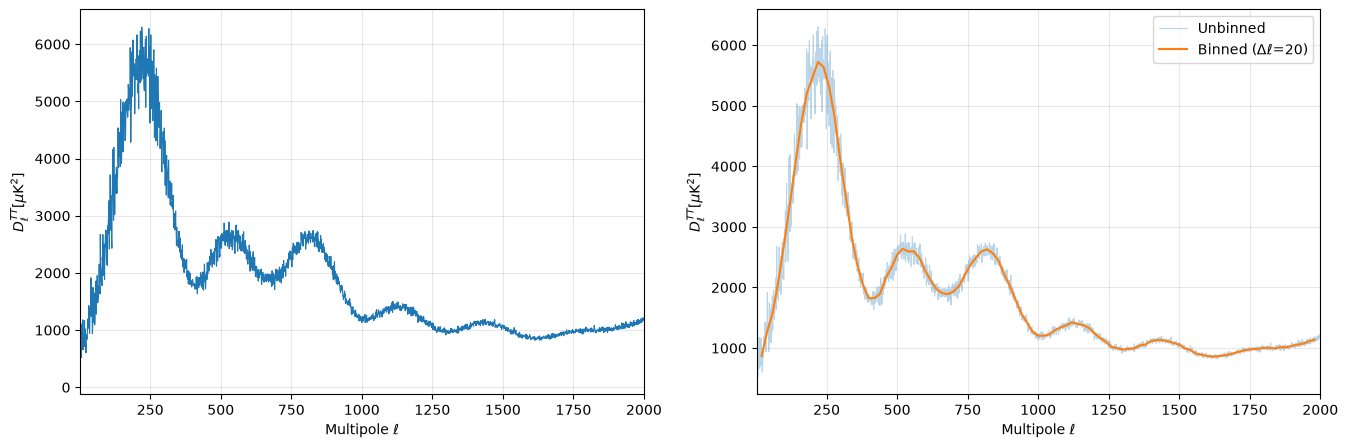

In [6]:
# ---- Power spectrum ----
lmin, lmax = 10, 2000
cl = hp.anafast(masked, lmax=lmax) #NOTE: anafast= analyzes a map and returns the power spectrum (C_l) up to lmax
                                   # and synfast= synthesizes a map from a given power spectrum (C_l) up to lmax

f_sky = np.mean(mask**2)
bl = hp.gauss_beam(np.radians(5/60), lmax=lmax)   # 5' beam
pl = hp.pixwin(2048)[:lmax+1]
cl = cl / (f_sky * bl**2 * pl**2)

ell = np.arange(lmax + 1)
dl = ell * (ell + 1) * cl / (2 * np.pi)

fig, ax= plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(ell[2:], dl[2:], lw=0.8)
ax[0].set_xlabel(r"Multipole $\ell$")
ax[0].set_ylabel(r"$D_\ell^{TT} [\mu\mathrm{K}^2]$")
ax[0].set_xlim(2, lmax)
ax[0].grid(alpha=0.3)

# group the multipoles into bands of width bin, and compute the mean of each band
ell= ell[2:]
dl_obs= dl[2:]
bin= 20

edges   = np.arange(lmin, lmax + 1, bin)
bin_idx = [np.where((ell >= edges[b]) & (ell < edges[b+1]))[0] for b in range(len(edges) - 1)]

def bin_it(y):
    return np.array([y[i].mean() for i in bin_idx])

l_eff  = bin_it(ell.astype(float))
D_data = bin_it(dl_obs)

ax[1].plot(ell[2:], dl_obs[2:], lw=0.8, alpha=0.3, label="Unbinned")
ax[1].plot(l_eff, D_data, lw=1.5, label=f"Binned (Δℓ={bin})")
ax[1].set_xlabel(r"Multipole $\ell$")
ax[1].set_ylabel(r"$D_\ell^{TT} [\mu\mathrm{K}^2]$")
ax[1].set_xlim(2, lmax)
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.savefig("Saved Data/Angular_Power_Spectrum(Binned+Unbinned).png", dpi=300, bbox_inches="tight")

plt.show()

## Saving the $\ell$ vs $C_\ell$ (and $D_\ell$) file 

In [ ]:
# Create a 3-column array: [ell, Cl, Dl]
# NOTE: cell 4 rebinds ell to ell[2:], so rebuild the full-length axis here
# to keep all three columns the same length (0..lmax).
data_to_save = np.column_stack((np.arange(lmax + 1), cl, dl))

# Save as a text/CSV file
np.savetxt(
    "Saved Data/APS_anafast.txt",
    data_to_save,
    header="ell Cl Dl",
    fmt=["%d", "%.18e", "%.18e"],
    comments="",)

---

---
# Conclusion

This notebook turns the raw COMMANDER map into the power spectrum every other CMB
notebook uses. Three corrections matter:

**Masking.** The Galactic plane outshines the CMB, so it is cut. Losing sky area
lowers the measured power, corrected by dividing by $f_{\rm sky} = \langle W^2 \rangle$.

**Beam and pixel window.** The instrument and the pixelisation both smooth the sky,
suppressing high $\ell$. Undoing this gives

$$C_\ell^{\rm corr} = \frac{C_\ell^{\rm raw}}{f_{\rm sky}\, b_\ell^2\, p_\ell^2}$$

**Binning.** At each multipole there are only $2\ell+1$ independent modes, so the raw
$C_\ell$ are too noisy to use point by point.

The acoustic peaks come out clearly, which is the point: their positions and relative
heights carry the cosmology fitted later.

**Main caveat, inherited by every downstream fit.** Masking correlates neighbouring
multipoles and the $1/f_{\rm sky}$ rescaling only corrects this approximately. The full
treatment is the MASTER coupling matrix. This is the main reason the fitted $H_0$ in
`CMB_MCMC_adaptive.ipynb` sits below Planck's published value: the sampler is fine, the
spectrum it is given is slightly biased.

Output: `Saved Data/APS_anafast.txt`.